# 01 - Primary Analysis: PaySim Financial Transaction Dataset

**Project:** Anomaly Watchers - Fraud Detection Pipeline  
**Dataset:** Kaggle PaySim Synthetic Mobile-Money Transactions  
**Objective:** Transform raw transaction data into a clean Feature Matrix suitable for incremental online-learning classifiers.

---

### Notebook Roadmap

| Phase | Section                                | Purpose                                                                                     |
| ----- | -------------------------------------- | ------------------------------------------------------------------------------------------- |
| 1     | Import Libraries and Data Ingestion    | Load dependencies, configure logger, and establish memory-efficient streaming.              |
| 2     | Exploratory Data Analysis (EDA)        | Measure class skew and analyze fraud distribution across transaction types.                 |
| 3     | Data Leakage Prevention                | Remove post-transaction features to ensure rigorous pre-transaction classification.         |
| 4     | Feature Engineering                    | Construct financial ratios, logarithmic transforms, and cyclical temporal features.         |
| 5     | One-Hot Encoding & Dummy Variable Trap | Encode categorical variables while preserving matrix rank and resolving multicollinearity.  |
| 6     | Modular Pipeline Encapsulation         | Assemble the ETL pipeline using Pandas `.pipe()` and validate the schema.                   |
| 7     | Train/Test Splitting & Leakage Defense | Isolate a clean test set prior to synthetic minority oversampling (SMOTE).                  |
| 8     | Three-Model Pipeline Execution         | Train Baseline (LR), Primary (XGBoost + SMOTE), and Unsupervised (Isolation Forest) models. |
| 9     | Business-Centric Evaluation & XAI      | Evaluate via AUPRC/F1-Score, analyze Confusion Matrices, and extract Feature Importances.   |
| 10    | Artifact Serialization                 | Export pipeline and trained models strictly to the backend directory for API integration.   |

---


## 1. Import Libraries and Data Ingestion

We begin by preparing our Python environment and importing the core libraries required for this analysis.  
The column names from the raw Kaggle export use inconsistent formatting (`nameOrig`, `oldbalanceOrg`, etc.).  
We will immediately rename them to clean, standard `snake_case` format so that every following step refers to a clear and unified structure.


### 1.1 Import Libraries

We skip installing over the existing Jupyter kernel and directly import the necessary libraries, relying on the OS-optimised versions installed in the environment.


In [1]:
# =====================================================================
# 1.1.1 Define SimpleLogger (to print color-coded log messages)
# =====================================================================

class SimpleLogger:
    def __init__(self):
        self.CYAN = '\033[96m'
        self.GREEN = '\033[92m'
        self.YELLOW = '\033[93m'
        self.RED = '\033[91m'
        self.RESET = '\033[0m'
    def info(self, msg): print(f"{self.CYAN}[INFO] {msg}{self.RESET}")
    def success(self, msg): print(f"{self.GREEN}[SUCCESS] {msg}{self.RESET}")
    def warning(self, msg): print(f"{self.YELLOW}[WARNING] {msg}{self.RESET}")
    def error(self, msg): print(f"{self.RED}[ERROR] {msg}{self.RESET}")

logger = SimpleLogger()

In [2]:
# =====================================================================
# 1.1.2 Dependency Manager
# =====================================================================

import sys
import subprocess
import importlib.metadata
import os
import io

# Define required packages (Import Name : Install Name)
REQUIRED_PACKAGES = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'kagglehub': 'kagglehub',
    'dotenv': 'python-dotenv',
    'xgboost': 'xgboost',
    'imblearn': 'imbalanced-learn',
    'sklearn': 'scikit-learn'
}

In [3]:
# =====================================================================
# 1.1.3 Setup Environment & Install Missing Libraries
# =====================================================================

def setup_environment():
    """Checks for required packages and securely installs only those missing."""
    logger.info("Initiating Dependency Manager...")
    installed_packages = {pkg.metadata['Name'].lower() for pkg in importlib.metadata.distributions()}
    
    for import_name, install_name in REQUIRED_PACKAGES.items():
        if install_name.lower() not in installed_packages:
            logger.warning(f"{install_name} missing. Installing into active kernel...")
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', install_name])
            logger.success(f"{install_name} installed.")
        else:
            pass # Package exists, skip to comply with strict environment rules
            
# Execute Environment Setup
setup_environment()

[INFO] Initiating Dependency Manager...


In [4]:
# =====================================================================
# 1.1.4 Imports Libraries Safely
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from dotenv import load_dotenv

c:\Users\quynh\Desktop\COS30049\code\anomaly-watchers-donutpuff\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# =====================================================================
# 1.1.5 Dynamically Report Environment Versions for Reproducibility
# =====================================================================

logger.info("Environment Versions:")
logger.info(f"Python     : {sys.version.split()[0]}")
for import_name, install_name in REQUIRED_PACKAGES.items():
    try:
        version = importlib.metadata.version(install_name)
        logger.info(f"{install_name.ljust(10)} : {version}")
    except importlib.metadata.PackageNotFoundError:
        logger.error(f"Failed to resolve version for {install_name}")

logger.success("All libraries imported and validated successfully.")

[INFO] Environment Versions:
[INFO] Python     : 3.13.5
[INFO] pandas     : 3.0.1
[INFO] numpy      : 2.4.3
[INFO] matplotlib : 3.10.8
[INFO] seaborn    : 0.13.2
[INFO] kagglehub  : 1.0.0
[INFO] python-dotenv : 1.2.2
[INFO] xgboost    : 3.2.0
[INFO] imbalanced-learn : 0.14.1
[INFO] scikit-learn : 1.8.0
[SUCCESS] All libraries imported and validated successfully.


### 1.2 Secure Data Ingestion (KaggleHub)

The full PaySim CSV contains over 6 million rows. Loading it in a single `pd.read_csv()` call risks Out-Of-Memory (OOM) crashes on constrained hardware.  
We adopt a chunked streaming approach: `pd.read_csv(..., chunksize=100_000)` creates a lazy iterator; we extract only the **first chunk** for exploratory analysis.

A separate persistent reference `raw_chunk` is saved. This is the immutable source that `build_feature_matrix()` in Section 6 operates on, guaranteeing the EDA and pipeline validation always start from identical raw data.


In [6]:
# 1. Initialize Environment & Memory Mapping
load_dotenv()
logger.info("Initializing Secure Data Ingestion...")

# Strict memory typing to compress the 6.3M rows and prevent system RAM OOM crashes
dtype_map = {
    'step': 'int16',
    'type': 'category',
    'amount': 'float32',
    'nameOrig': 'object',
    'oldbalanceOrg': 'float32',
    'newbalanceOrig': 'float32',
    'nameDest': 'object',
    'oldbalanceDest': 'float32',
    'newbalanceDest': 'float32',
    'isFraud': 'int8',
    'isFlaggedFraud': 'int8'
}

# 2. Verify Authentication Context
if os.environ.get('KAGGLE_USERNAME'):
    logger.info("Kaggle credentials verified in environment.")
else:
    logger.warning("Kaggle credentials not found. Public datasets may still download anonymously.")

try:
    # 3. Securely fetch the target dataset payload via Kaggle API
    logger.info("Requesting 'ealaxi/paysim1' dataset from Kaggle...")
    dataset_path = kagglehub.dataset_download("ealaxi/paysim1")
    logger.success(f"Dataset securely downloaded/located at: {dataset_path}")

    # 4. Locate the specific CSV file within the payload directory
    csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
    
    if not csv_files:
        logger.error(f"No CSV files found in the target directory: {dataset_path}")
    else:
        csv_file_path = os.path.join(dataset_path, csv_files[0])
        logger.info(f"Target CSV located: '{csv_files[0]}'. Loading entirely into memory...")

        # 5. Direct Memory Load
        # Relies entirely on dtype_map to survive the ~6.3 million row memory allocation
        raw_df = pd.read_csv(csv_file_path, dtype=dtype_map)
        
        logger.success("Full dataset successfully loaded into memory.")
        
        # 6. Initialize working DataFrame
        df = raw_df.copy()
        logger.success(f"Working DataFrame initialised. Shape: {df.shape}")
        display(df.head())

except Exception as e:
    logger.error(f"Data ingestion pipeline failed. Error: {str(e)}")

[INFO] Initializing Secure Data Ingestion...
[INFO] Kaggle credentials verified in environment.
[INFO] Requesting 'ealaxi/paysim1' dataset from Kaggle...
[SUCCESS] Dataset securely downloaded/located at: C:\Users\quynh\.cache\kagglehub\datasets\ealaxi\paysim1\versions\2
[INFO] Target CSV located: 'PS_20174392719_1491204439457_log.csv'. Loading entirely into memory...
[SUCCESS] Full dataset successfully loaded into memory.
[SUCCESS] Working DataFrame initialised. Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0


### 1.3 Rename Columns to Snake Case

The raw Kaggle columns use inconsistent camelCase (e.g., `nameOrig`, `oldbalanceOrg`).  
We define the pure function `rename_to_snake_case()` and immediately execute it on `df`, establishing a consistent `snake_case` schema for the entire pipeline.


In [7]:
def rename_to_snake_case(df):
    """Rename raw Kaggle camelCase columns to a unified snake_case schema."""
    COLUMN_MAP = {
        "step":            "step",
        "type":            "transaction_type",
        "amount":          "transaction_amount",
        "nameOrig":        "originator_id",
        "oldbalanceOrg":   "originator_old_balance",
        "newbalanceOrig":  "originator_new_balance",
        "nameDest":        "destination_id",
        "oldbalanceDest":  "destination_old_balance",
        "newbalanceDest":  "destination_new_balance",
        "isFraud":         "is_fraud",
        "isFlaggedFraud":  "is_flagged_fraud",
    }
    return df.rename(columns=COLUMN_MAP)

df = rename_to_snake_case(df)

logger.success("Columns renamed to snake_case schema:")
logger.info(str(df.columns.tolist()))

[SUCCESS] Columns renamed to snake_case schema:
[INFO] ['step', 'transaction_type', 'transaction_amount', 'originator_id', 'originator_old_balance', 'originator_new_balance', 'destination_id', 'destination_old_balance', 'destination_new_balance', 'is_fraud', 'is_flagged_fraud']


---

## 2. Exploratory Data Analysis (EDA) and the Imbalance Problem


### Why Accuracy Can Be Misleading

Financial fraud datasets are **extremely imbalanced**. Legitimate transactions routinely outnumber fraudulent ones by ratios of 500:1 or greater.  
A simple model that predicts _"not fraud"_ for every single transaction would achieve **over 99% accuracy** while catching **zero** actual fraud.

Accuracy heavily favors the majority class:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

When $TN \gg TP$, the metric is dominated by true-negatives and becomes misleading for the minority class.

#### Metrics We Will Rely On Instead

| Metric                                        | Why It Matters                                                                                               |
| --------------------------------------------- | ------------------------------------------------------------------------------------------------------------ |
| **AUPRC** (Area Under Precision-Recall Curve) | Directly measures the precision-recall trade-off on the minority class; unaffected by the large TN count.    |
| **F1-Score**                                  | Harmonic mean of Precision and Recall. It penalises models that sacrifice one for the other.                 |
| **Recall @ fixed Precision**                  | In production, the business sets a minimum precision (e.g., 90%) and maximises recall under that constraint. |

> **Note:** All model evaluation in later sections will report **AUPRC** as the primary metric and **F1-Score** as the secondary metric. Accuracy will only be logged but never used to judge model success.


### 2.1 Visualise the Class Distribution

We plot the number of legitimate vs. fraudulent transactions on a **log-scaled** y-axis so that both classes are clearly visible despite the extreme imbalance.


[INFO] Class Distribution:
is_fraud
0    6354407
1       8213
[INFO] Fraud prevalence: 0.1291 %


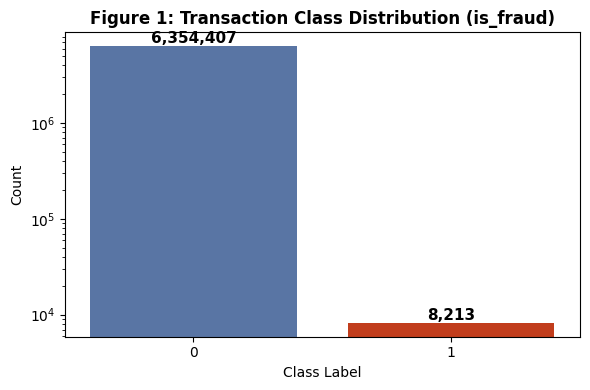

In [8]:
fraud_counts = df["is_fraud"].value_counts()
fraud_pct    = df["is_fraud"].value_counts(normalize=True) * 100

logger.info(f"Class Distribution:\n{fraud_counts.to_string()}")
logger.info(f"Fraud prevalence: {fraud_pct[1]:.4f} %")

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x="is_fraud", data=df, ax=ax,
              hue="is_fraud", palette={0: "#4C72B0", 1: "#DD2C00", "0": "#4C72B0", "1": "#DD2C00"}, legend=False)
ax.set_title("Figure 1: Transaction Class Distribution (is_fraud)", fontweight="bold")
ax.set_xlabel("Class Label")
ax.set_ylabel("Count")
ax.set_yscale("log")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

**Observation:** The transactions are overwhelmingly legitimate, with fraudulent events making up a marginal fraction of the dataset, producing extreme class imbalance.

**Implication:** Calculating global accuracy mathematically rewards simple models that exclusively predict the majority class - a basic all-legitimate classifier achieves 99%+ accuracy while catching zero fraud. The large TN count dominates the Accuracy formula ($\frac{TP+TN}{TP+TN+FP+FN}$), rendering it a potentially misleading metric in FinTech.

**Decision:** We avoid Accuracy as a validation metric and focus downstream tuning around AUPRC (Area Under the Precision-Recall Curve) and F1-Score, which are immune to majority-class inflation.


### 2.2 Analyse Fraud Distribution Across Transaction Types

Not all transaction types carry the same fraud risk. We compute the absolute fraud count and the fraud rate (%) for each `transaction_type` to understand where fraud is happening.


[INFO] Fraud breakdown by transaction type:


,fraud_count,total_count,fraud_rate_%
transaction_type,,,
TRANSFER,4097,532909,0.7688
CASH_OUT,4116,2237500,0.1840
CASH_IN,0,1399284,0.0000
DEBIT,0,41432,0.0000
PAYMENT,0,2151495,0.0000


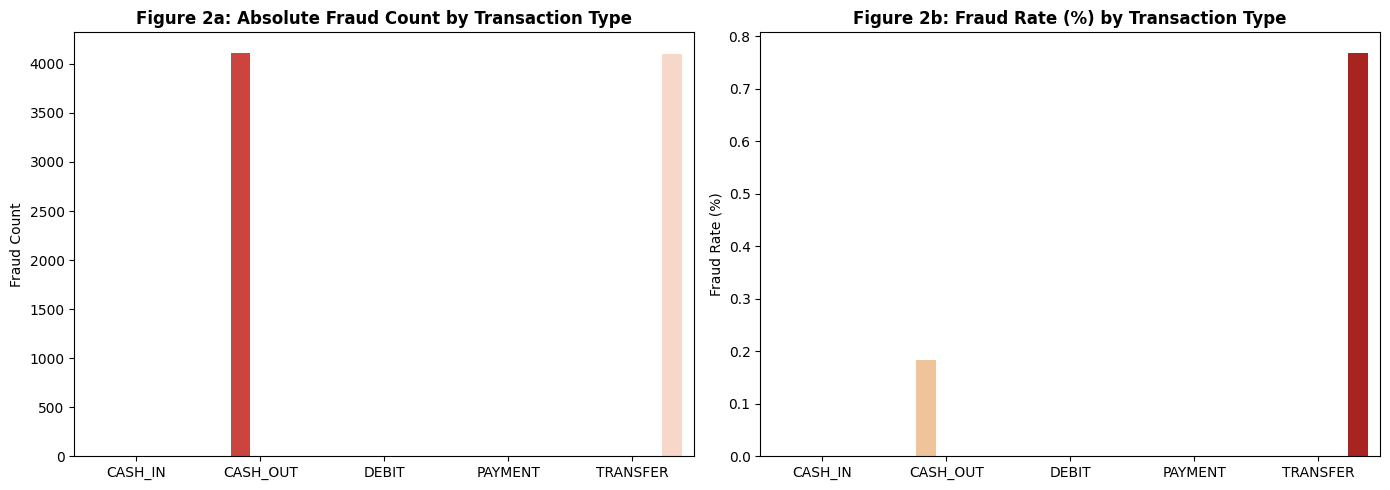

In [9]:
type_fraud = df.groupby("transaction_type")["is_fraud"].agg(["sum", "count"])
type_fraud.columns = ["fraud_count", "total_count"]
type_fraud["fraud_rate_%"] = (type_fraud["fraud_count"] / type_fraud["total_count"] * 100).round(4)
type_fraud = type_fraud.sort_values("fraud_rate_%", ascending=False)

logger.info("Fraud breakdown by transaction type:")
display(type_fraud)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute fraud count per type
sns.barplot(x=type_fraud.index, y="fraud_count", data=type_fraud,
            ax=axes[0], palette="Reds_r", hue=type_fraud.index, legend=False)
axes[0].set_title("Figure 2a: Absolute Fraud Count by Transaction Type", fontweight="bold")
axes[0].set_ylabel("Fraud Count")
axes[0].set_xlabel("")

# Right: fraud rate (%) per type
sns.barplot(x=type_fraud.index, y="fraud_rate_%", data=type_fraud,
            ax=axes[1], palette="OrRd", hue=type_fraud.index, legend=False)
axes[1].set_title("Figure 2b: Fraud Rate (%) by Transaction Type", fontweight="bold")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

**Observation:** Fraudulent activity is entirely localized within `TRANSFER` and `CASH_OUT` transaction types, with all other categories yielding zero positive fraud cases.

**Implication:** The `transaction_type` variable possesses high predictive power (high mutual information with `is_fraud`), serving as an exceptional categorical discriminator. In financial fraud contexts, criminals exploit the irreversible nature of transfer and cash-out operations - funds are immediately moved out of reach before detection.

**Decision:** We must one-hot encode `transaction_type` via `encode_categoricals_and_drop_identifiers()` to preserve this discriminatory power, ensuring the model can geometrically isolate decision boundaries conditioned on `TRANSFER` and `CASH_OUT`.


---

## 3. Data Leakage Prevention


### What Is Data Leakage?

**Data leakage** occurs when the training data contains information that would **not be available at prediction time** in a real-world system.  
A model trained on leaked features will appear to perform well during offline evaluation but will fail in real usage.

In a live banking API, the fraud-detection model is called **before** the transaction is accepted and processed.  
At prediction time, we know:

- The requested `transaction_amount`
- The current (`old`) balances of both accounts

We do **not** know:

- The **post-transaction** (`new`) balances, because the bank has not yet processed the transaction.

If we include `originator_new_balance` or `destination_new_balance` as features, we give the model information from the "future".  
The model will easily learn that `new_balance = old_balance - amount` for legitimate transactions and flag any differences.  
This is **not a true pattern of fraud**; it is just a mathematical side-effect that will not exist when we try to detect fraud in real-time.

> **Strategy:** We always drop these columns before doing any feature engineering to make sure our algorithm only sees information that would truly be available.


### 3.1 Drop Leaked Post-Transaction Balance Columns

We remove the `originator_new_balance` and `destination_new_balance` columns from the DataFrame.


In [10]:
LEAKED_COLUMNS = [
    "originator_new_balance", 
    "destination_new_balance", 
    "is_flagged_fraud"
    ]

def drop_post_transaction_leaks(df):
    """Remove columns that represent post-transaction state — unavailable at real-time prediction."""
    return df.drop(columns=LEAKED_COLUMNS)

df = drop_post_transaction_leaks(df)

logger.success(f"Dropped post-transaction leaked columns: {LEAKED_COLUMNS}")
logger.info(f"Remaining DataFrame shape: {df.shape}")

[SUCCESS] Dropped post-transaction leaked columns: ['originator_new_balance', 'destination_new_balance', 'is_flagged_fraud']
[INFO] Remaining DataFrame shape: (6362620, 8)


---

## 4. Feature Engineering


### Why Raw Data Needs Engineering

Machine learning models often struggle with two common properties of raw financial data:

1. **Unbounded monetary values:** Transaction amounts and account balances span huge ranges (e.g., $0.01 to $10,000,000).  
   These raw values create skewed distributions. We use **logarithmic transforms** (`np.log1p`) to compress the range down while keeping the general order.

2. **Linear passing of time:** The `step` feature represents hours elapsed since the data started. A machine learning model cannot naturally understand that hour 23 and hour 0 are next to each other in a standard day.  
   We use **trigonometric time encoding** to map the hour into a circle shape:

   $$
   \text{hour\_sin} = \sin\!\left(\frac{2\pi \cdot \text{step}}{24}\right), \quad
   \text{hour\_cos} = \cos\!\left(\frac{2\pi \cdot \text{step}}{24}\right)
   $$

   This mathematically links hour 23 and 0 closer together.

3. **Contextless numbers:** A $5,000 transaction means something different when the sender has $50,000 versus $5,001 in their account.  
   We create **ratio features** (dividing amount by balance) to capture this important context directly.

### Summary of New Features Created

| Feature                       | Formula                       | Idea                                                                                                    |
| ----------------------------- | ----------------------------- | ------------------------------------------------------------------------------------------------------- |
| `amount_to_destination_ratio` | `amount / (dest_old_bal + e)` | How large is the incoming amount relative to the destination's existing balance?                        |
| `account_drain_ratio`         | `amount / (orig_old_bal + e)` | What fraction of the sender's balance is being spent? Fraud often completely empties an account (100%). |
| `log_transaction_amount`      | `log1p(amount)`               | Compresses the monetary scale to deal with extreme outliers.                                            |
| `time_hour_sin`               | `sin(2 * pi * step / 24)`     | Y-coordinate over a 24-hour cycle.                                                                      |
| `time_hour_cos`               | `cos(2 * pi * step / 24)`     | X-coordinate over a 24-hour cycle.                                                                      |

> **Note:** We add a tiny number `e = 1e-5` to the bottom of our fractions to avoid division-by-zero errors when balances are exactly 0.


### 4.1 Create Ratio Features

We create two new columns that capture how the transaction size compares to the starting balances of the sender and receiver.


In [11]:
def engineer_financial_ratios(df):
    """Construct ratio features expressing transaction magnitude relative to account balances."""
    EPSILON = 1e-5
    df = df.copy()
    df["amount_to_destination_ratio"] = (
        df["transaction_amount"] / (df["destination_old_balance"] + EPSILON)
    )
    df["account_drain_ratio"] = (
        df["transaction_amount"] / (df["originator_old_balance"] + EPSILON)
    )
    return df

df = engineer_financial_ratios(df)

logger.success("Ratio features created: 'amount_to_destination_ratio', 'account_drain_ratio'")

[SUCCESS] Ratio features created: 'amount_to_destination_ratio', 'account_drain_ratio'


### 4.2 Apply Logarithmic Transform to Amount

We apply `np.log1p` (which calculates the natural log of 1 + x). This helps compress massive transaction amounts so they don't break the model.


**Why is a Logarithmic Transform Necessary?**
Let's look at the massive skew in the raw numerical data. A heavily skewed right-tail means that high-value transactions act as extreme outliers, which can affect gradient updates in tree-based algorithms and linear separation.


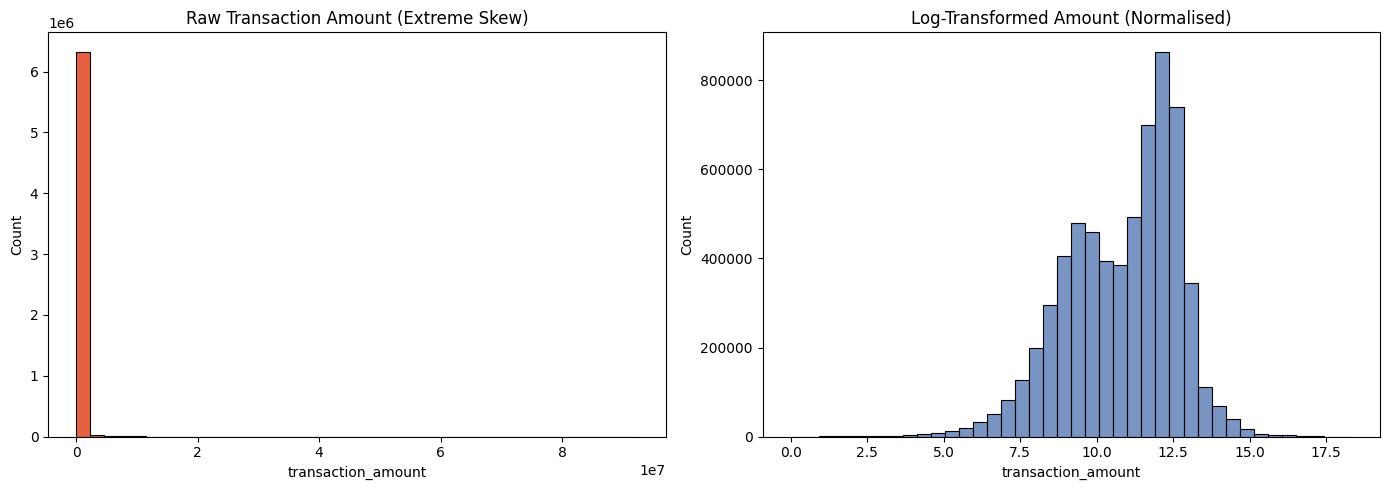

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Raw distribution (heavily skewed)
sns.histplot(df['transaction_amount'], bins=40, ax=axes[0], color='#DD2C00')
axes[0].set_title('Raw Transaction Amount (Extreme Skew)')
axes[0].set_ylabel('Count')

# Plot 2: Log-transformed distribution (normalized)
sns.histplot(np.log1p(df['transaction_amount']), bins=40, ax=axes[1], color='#4C72B0')
axes[1].set_title('Log-Transformed Amount (Normalised)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Observation:** The raw `transaction_amount` distribution exhibits severe right-skew, with the vast majority of values clustered near zero and a long tail extending to millions. The log-transformed version collapses this into a near-Gaussian bell curve.

**Implication:** Extreme monetary outliers can affect model training disproportionately. Logarithmic compression via `np.log1p()` maps the exponential monetary domain into a stabilized linear space, allowing all transaction sizes to contribute proportionally to the model's optimization loss.

**Decision:** We permanently apply `np.log1p()` to `transaction_amount` inside `apply_logarithmic_transforms()`. The raw column is discarded subsequently by `drop_redundant_raw_columns()` to prevent duplicate signal leakage into the Feature Matrix.


In [13]:
def apply_logarithmic_transforms(df):
    """Apply np.log1p to compress transaction_amount's exponential monetary scale."""
    df = df.copy()
    df["log_transaction_amount"] = np.log1p(df["transaction_amount"])
    return df

df = apply_logarithmic_transforms(df)

logger.success("Log-transformed transaction amount created: 'log_transaction_amount'")

[SUCCESS] Log-transformed transaction amount created: 'log_transaction_amount'


### 4.3 Apply Trigonometric Time Encoding

Each `step` in the dataset stands for 1 hour. We change this time into a 24-hour cycle using sine and cosine waves.


**Why is Trigonometric Time Encoding Necessary?**
Let's examine the 24-hour cycle of financial behavior. If we leave `step` purely as a linear integer, the model interprets hour 23 (11 PM) and hour 0 (midnight) as being numerically far apart (diff=23), even though they are chronologically adjacent (diff=1). We extract the `hour_of_day` and map its cyclical pattern.


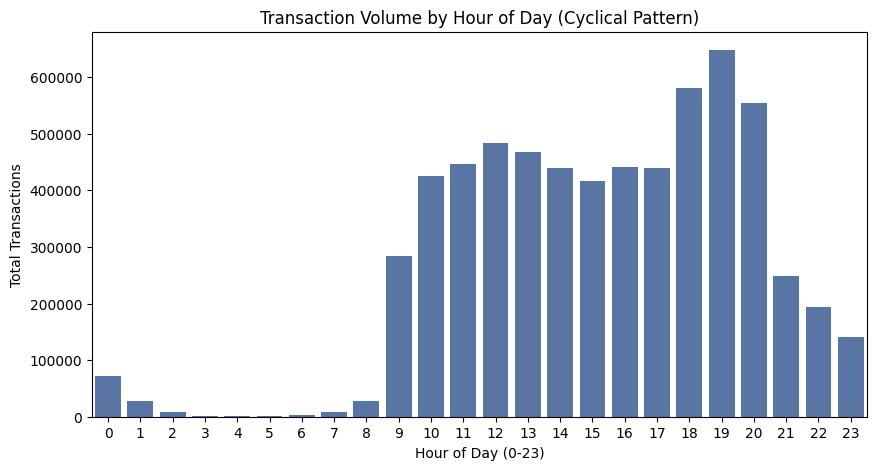

In [14]:
# Extract hour of the day (0-23)
hour_of_day = df["step"] % 24

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(x=hour_of_day, color="#4C72B0", ax=ax)
ax.set_title("Transaction Volume by Hour of Day (Cyclical Pattern)")
ax.set_xlabel("Hour of Day (0-23)")
ax.set_ylabel("Total Transactions")
plt.show()

**Observation:** Transaction volume follows a pronounced 24-hour cyclical rhythm (consistent low-activity periods during early morning hours (0-6) and peak activity mid-day) confirming the periodic temporal structure of financial behavior.

**Implication:** As a raw integer, `step` imposes false Euclidean distance between hour 23 and hour 0. Sine/cosine projection onto a unit circle, $\sin(2\pi \cdot h/24)$ and $\cos(2\pi \cdot h/24)$, encodes temporal proximity correctly, so that midnight-adjacent hours share near-identical feature vectors in the model's input space.

**Decision:** We apply trigonometric time encoding via `apply_cyclical_time_encoding()`, generating `time_hour_sin` and `time_hour_cos`. The raw `step` integer is discarded by `drop_redundant_raw_columns()` to eliminate the misleading linear representation.


In [15]:
def apply_cyclical_time_encoding(df):
    """Map the linear step integer onto a 24-hour sine/cosine unit circle."""
    HOURS_IN_DAY = 24
    df = df.copy()
    df["time_hour_sin"] = np.sin(2 * np.pi * df["step"] / HOURS_IN_DAY)
    df["time_hour_cos"] = np.cos(2 * np.pi * df["step"] / HOURS_IN_DAY)
    return df

df = apply_cyclical_time_encoding(df)

logger.success("Trigonometric time encoding applied: 'time_hour_sin', 'time_hour_cos'")

[SUCCESS] Trigonometric time encoding applied: 'time_hour_sin', 'time_hour_cos'


### 4.4 Drop Original Replaced Data

Because `originator_old_balance`, `destination_old_balance`, `transaction_amount` and `step` have been upgraded into new features, we remove the original columns to prevent data leakage and so we do not pass duplicate data to the model.


In [16]:
RAW_COLUMNS_TO_DROP = [
    "transaction_amount", 
    "step",
    "originator_old_balance",
    "destination_old_balance"
]

def drop_redundant_raw_columns(df):
    """Remove original raw columns superseded by engineered features to prevent data leakage."""
    return df.drop(columns=RAW_COLUMNS_TO_DROP)

df = drop_redundant_raw_columns(df)
logger.success(f"Dropped superseded raw columns: {RAW_COLUMNS_TO_DROP}")
logger.info(f"Current shape: {df.shape}")

[SUCCESS] Dropped superseded raw columns: ['transaction_amount', 'step', 'originator_old_balance', 'destination_old_balance']
[INFO] Current shape: (6362620, 9)


### 4.5 Distribution Analysis of Engineered Ratios

We plot a boxplot comparing the newly created `account_drain_ratio` for non-fraud vs. fraud classes to validate the structural hypotheses behind our feature engineering.


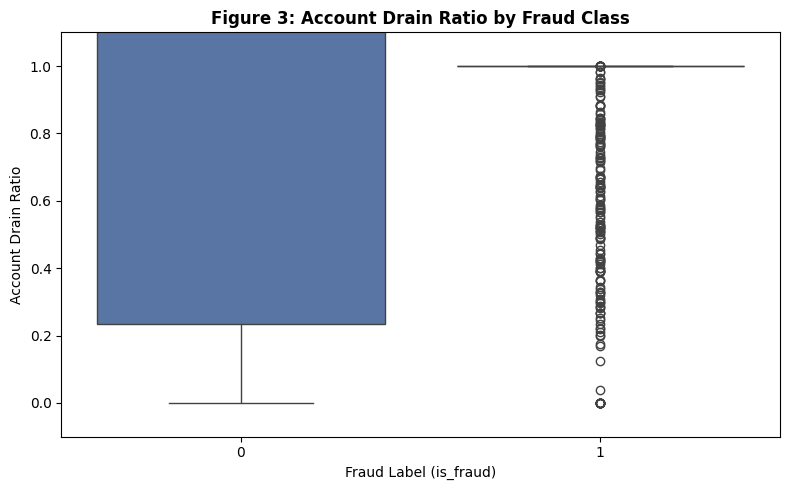

In [17]:
# Generate categorical boxplot to determine variance and interquartile separation between fraud classes to confirm feature validity
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x="is_fraud", y="account_drain_ratio", data=df, ax=ax, hue="is_fraud", palette={0: "#4C72B0", 1: "#DD2C00", "0": "#4C72B0", "1": "#DD2C00"}, legend=False)
ax.set_title("Figure 3: Account Drain Ratio by Fraud Class", fontweight="bold")
ax.set_xlabel("Fraud Label (is_fraud)")
ax.set_ylabel("Account Drain Ratio")

# Limit the y-axis to eliminate noise from extreme outliers and focus exclusively on the distribution body
ax.set_ylim(-0.1, 1.1)
plt.tight_layout()
plt.show()


**Observation:** Fraudulent transactions routinely display an `account_drain_ratio` firmly pinned near 1.0 (indicating near-complete account depletion), whereas legitimate transactions span a highly varied, diffuse distribution.

**Implication:** The engineered ratio helps identify a threshold boundary that was previously less obvious when analyzing the unstructured raw balance columns. In financial fraud contexts, attackers systematically drain accounts to maximize value extraction before detection. This behavioral pattern manifests directly as a ratio spike toward 1.0.

**Decision:** We include `account_drain_ratio` into the primary Feature Matrix via `engineer_financial_ratios()`. Its strong class-separability confirms it is a key feature for the downstream models.


---

## 5. One-Hot Encoding and the Dummy Variable Trap


### Understanding the Dummy Variable Trap

When we convert a text category with $k$ options into a set of 1s and 0s (One-Hot Encoding), it results in $k$ separate columns.  
However, this creates a problem called **perfect multicollinearity**: you can perfectly calculate the value of any one column just by looking at the others.  
This breaks the math behind many prediction models.

$$
x_{\text{CASH\_IN}} = 1 - x_{\text{CASH\_OUT}} - x_{\text{DEBIT}} - x_{\text{PAYMENT}} - x_{\text{TRANSFER}}
$$

**Solution:** We purposely delete one of the dummy columns (in this case, `transaction_type_CASH_IN`). By doing this, the model implies `CASH_IN` when all the other type columns are 0.  
This fixes the mathematical error and loses no actual information.

Note: We also drop the string-based identifier columns (`originator_id`, `destination_id`) since they act like endless categories that provide no learning value.


### 5.1 Encode Transaction Types, Resolve Dummy Trap & Remove High-Cardinality Identifiers

All three encoding and cleanup steps are combined into a single function `encode_categoricals_and_drop_identifiers()`, keeping the process clean.


#### 5.1.1 One-Hot Encode the Transaction Type

We use the pandas get_dummies function to convert transaction_type into separated 1 and 0 columns.


#### 5.1.2 Drop the Reference Dummy (CASH_IN) to Fix the Trap

Dropping `transaction_type_CASH_IN` eliminates perfect multicollinearity. The model infers CASH_IN when all remaining type dummies evaluate to zero. This is performed inside the function above.


#### 5.1.3 Remove High-Cardinality Identifiers

`originator_id` and `destination_id` are unique per-account string tokens. They provide little generalizable signal, presenting only a memorization risk. Both are discarded inside the function above.


In [18]:
def encode_categoricals_and_drop_identifiers(df):
    """
    Transformation steps covering three pipeline steps:
      Step 1 - One-hot encode 'transaction_type' into binary indicator columns.
      Step 2 - Drop the CASH_IN reference dummy to neutralise the Dummy Variable Trap.
      Step 3 - Rename dummies to readable snake_case labels.
      Step 4 - Drop high-cardinality string identifiers that have no modelling value.
    """
    DUMMY_RENAME = {
        "transaction_type_CASH_OUT": "is_type_cash_out",
        "transaction_type_DEBIT":    "is_type_debit",
        "transaction_type_PAYMENT":  "is_type_payment",
        "transaction_type_TRANSFER": "is_type_transfer",
    }
    df = pd.get_dummies(df, columns=["transaction_type"], dtype=int)
    df = df.drop(columns=["transaction_type_CASH_IN"])
    df = df.rename(columns=DUMMY_RENAME)
    df = df.drop(columns=["originator_id", "destination_id"])
    return df

df = encode_categoricals_and_drop_identifiers(df)

logger.success("Encoding and identifier removal complete.")
logger.info(f"Columns after encoding: {df.columns.tolist()}")
logger.info(f"Shape: {df.shape}")

[SUCCESS] Encoding and identifier removal complete.
[INFO] Columns after encoding: ['is_fraud', 'amount_to_destination_ratio', 'account_drain_ratio', 'log_transaction_amount', 'time_hour_sin', 'time_hour_cos', 'is_type_cash_out', 'is_type_debit', 'is_type_payment', 'is_type_transfer']
[INFO] Shape: (6362620, 10)


### 5.2 Check for Perfect Multicollinearity

We generate a correlation heatmap to check that our dummy-variable handling resolved collinearity issues within the terminal matrix.


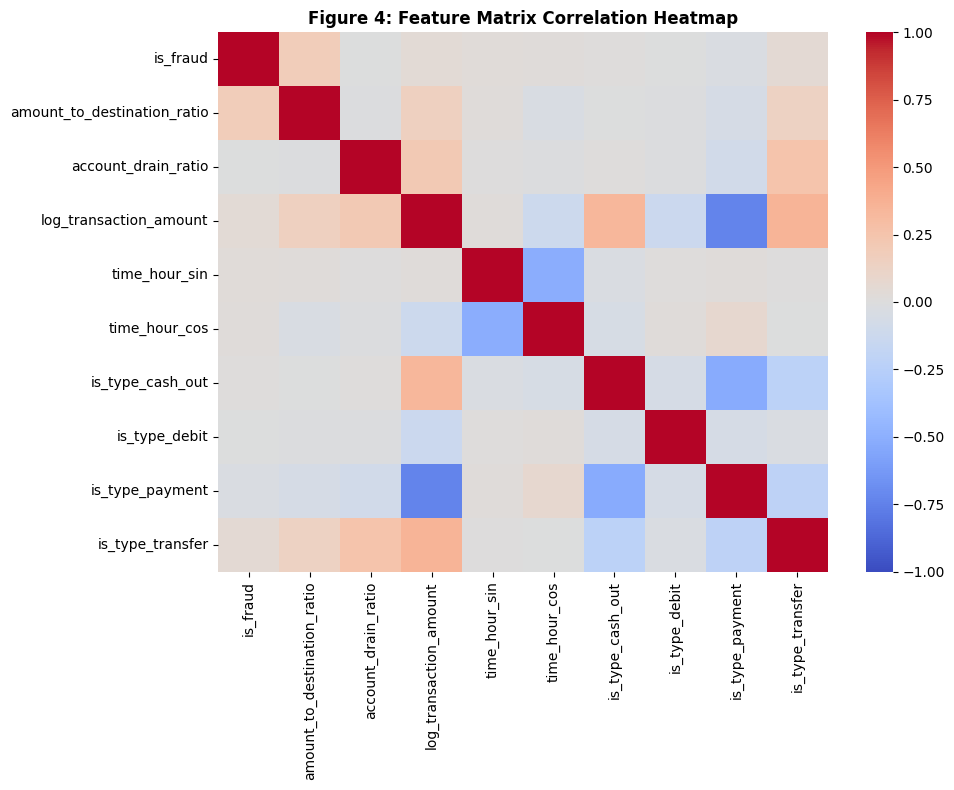

In [19]:
# Compute Pearson product-moment correlation coefficients to verify the independence of constructed features
corr_matrix = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, fmt=".2f", ax=ax, vmin=-1, vmax=1)
ax.set_title("Figure 4: Feature Matrix Correlation Heatmap", fontweight="bold")
plt.tight_layout()
plt.show()

**Observation:** No off-diagonal matrix subsets exhibit near-1.0 or near−1.0 correlations. The Feature Matrix is structurally orthogonal after OHE and dummy-trap resolution.

**Implication:** Perfect multicollinearity can destabilize linear models and create redundant splits in tree-based models. The absence of extreme correlations confirms that each feature contributes independent information, and the matrix has full numerical rank and the dummy-variable trap has been successfully neutralized.

**Decision:** We use this DataFrame for the next steps. `encode_categoricals_and_drop_identifiers()` produces a numerically sound Feature Matrix that can be ingested by any downstream gradient-descent algorithm.


---

## 6. Modular Pipeline Encapsulation


### Applying the DRY Principle: `build_feature_matrix()`

Each function defined in Sections 1-5 is now chained into a single pipeline using Pandas `.pipe()`. This architecture guarantees:

- **DRY (Don't Repeat Yourself):** All schema logic lives in one authoritative function. The FastAPI backend's `/predict` endpoint calls `build_feature_matrix()` identically on each incoming inference payload, ensuring alignment between training-time and production-time feature construction.
- **Reproducibility:** The pipeline is deterministic. `df_raw` is never mutated (`.copy()` is applied at entry).
- **Testability:** Each function can be unit-tested independently; the main pipeline can be integration-tested end-to-end.

> **Usage Note:** The FastAPI `/predict` endpoint must invoke `build_feature_matrix()` on any incoming JSON payload **before** calling `model_primary.predict_proba()`. This is the sole authorised path for feature construction.

### 6.1 Finalized Schema

| # | Feature Name | Role | Mathematical / Logic Transformation | Business & Security Justification (The "Why") |
| --- | --- | --- | --- | --- |
| 1 | **`is_fraud`**                    | Target Label      | Boolean                                 | The ground-truth indicator of illicit activity. Used as the supervisory signal for XGBoost and Logistic Regression. |
| 2 | **`amount_to_destination_ratio`** | Impact Magnitude  | $\frac{amount}{dest\_old\_balance + 1}$ | Detects anomalous inflows. Compares the sent money to the receiver's current balance. If a nearly empty account suddenly receives an amount that is 1,000x its usual balance, it is a high-confidence signal of illicit activity. |
| 3 | **`account_drain_ratio`**         | Intent Indicator  | $\frac{amount}{orig\_old\_balance + 1}$ | Measures what percentage of the sender's total money is being moved. While regular users spend small portions of their wealth, fraudsters typically try to "drain" 100% of an account's value in a single go before they are caught. |
| 4 | **`log_transaction_amount`**      | Scaling           | $\ln(amount + 1)$                       | Log-transformation normalizes the data. In banking, most transactions are small, but a few are huge. This mathematical "shrinkage" makes sure the model treats all transaction sizes fairly, preventing a single multi-million dollar transfer from confusing the model's logic. |
| 5 | **`time_hour_sin`**               | Temporal Cycle    | $\sin(\frac{2\pi \cdot hour}{24})$      | A mathematical way to tell the computer that time is a circle. It ensures the model understands that 11:59 PM and 12:01 AM are right next to each other, which is crucial for spotting fraud that happens in the middle of the night. |
| 6 | **`time_hour_cos`**               | Temporal Cycle    | $\cos(\frac{2\pi \cdot hour}{24})$      | Works with the Sine feature above to give the model a precise "map" of the 24-hour clock. Together, they allow the model to learn exactly which hours of the day (like 3:00 AM) are the highest risk for unauthorized transfers. |
| 7 | **`is_type_cash_out`**            | Vector Indicator  | One-Hot Encoding                        | Flags the "Exit Point." Fraudsters use this to turn digital stolen money into physical cash. Once money is cashed out at an ATM or agent, the bank can no longer "undo" the transaction, making this a high-risk indicator. |
| 8 | **`is_type_debit`**               | Vector Indicator  | One-Hot Encoding                        | Identifies everyday spending like bill payments or small purchases. Because these are rarely used for large-scale fraud, they help the model learn what "safe" and "boring" regular behavior looks like. |
| 9 | **`is_type_payment`**             | Vector Indicator  | One-Hot Encoding                        | Marks payments to merchants or businesses. These have a different risk level than person-to-person transfers, helping the model separate commercial transactions from personal account compromises. |
| 10 | **`is_type_transfer`**           | Vector Indicator  | One-Hot Encoding                        | Flags the primary way money is moved between individuals. This is the "high-speed" lane for fraud, as it allows a criminal to move stolen funds through multiple accounts quickly to hide their trail. |


In [20]:
def build_feature_matrix(df_raw):
    """
    Modular Pipeline.

    Chains all transformation functions via Pandas .pipe() to produce
    the canonical 12-column Feature Matrix from any raw PaySim-schema DataFrame.

    This is the sole authorised feature construction path for both training
    and the FastAPI production inference endpoint.
    """
    return (df_raw.copy()
            .pipe(rename_to_snake_case)
            .pipe(drop_post_transaction_leaks)
            .pipe(engineer_financial_ratios)
            .pipe(apply_logarithmic_transforms)
            .pipe(apply_cyclical_time_encoding)
            .pipe(drop_redundant_raw_columns)
            .pipe(encode_categoricals_and_drop_identifiers))


# Execute the complete pipeline to produce the Finalized Feature Matrix used by all downstream modelling sections.
logger.info("Executing end-to-end build_feature_matrix() pipeline for validation...")
df = build_feature_matrix(raw_df.copy())
logger.success(f"Pipeline complete. Output shape: {df.shape}")
logger.info(f"Output columns: {df.columns.tolist()}")

[INFO] Executing end-to-end build_feature_matrix() pipeline for validation...
[SUCCESS] Pipeline complete. Output shape: (6362620, 10)
[INFO] Output columns: ['is_fraud', 'amount_to_destination_ratio', 'account_drain_ratio', 'log_transaction_amount', 'time_hour_sin', 'time_hour_cos', 'is_type_cash_out', 'is_type_debit', 'is_type_payment', 'is_type_transfer']


### 6.2 Pipeline Validation

We buffer `df.info()` through the logger to confirm the output schema exactly matches the 12-column contract specified in Section 6.1.


In [21]:
logger.info("============================================================")
logger.info(" FINAL FEATURE MATRIX - SCHEMA REPORT")
logger.info("============================================================")

# Capture df.info() so it prints exclusively through our logger
buf = io.StringIO()
df.info(buf=buf)
logger.info(f"\n{buf.getvalue()}")

logger.success("First 5 rows:")
display(df.head())

[INFO] ============================================================
[INFO]  FINAL FEATURE MATRIX - SCHEMA REPORT
[INFO] ============================================================
[INFO] 
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   is_fraud                     int8   
 1   amount_to_destination_ratio  float32
 2   account_drain_ratio          float32
 3   log_transaction_amount       float32
 4   time_hour_sin                float64
 5   time_hour_cos                float64
 6   is_type_cash_out             int64  
 7   is_type_debit                int64  
 8   is_type_payment              int64  
 9   is_type_transfer             int64  
dtypes: float32(3), float64(2), int64(4), int8(1)
memory usage: 370.1 MB

[SUCCESS] First 5 rows:


,is_fraud,amount_to_destination_ratio,account_drain_ratio,log_transaction_amount,time_hour_sin,time_hour_cos,is_type_cash_out,is_type_debit,is_type_payment,is_type_transfer
0,0,9.839640e+08,0.057834,9.194276,0.258819,0.965926,0,0,1,0
1,0,1.864280e+08,0.087735,7.531167,0.258819,0.965926,0,0,1,0
2,1,1.810000e+07,1.000000,5.204007,0.258819,0.965926,0,0,0,1
3,1,8.544991e-03,1.000000,5.204007,0.258819,0.965926,1,0,0,0
4,0,1.166814e+09,0.280795,9.364703,0.258819,0.965926,0,0,1,0


### Summary

`build_feature_matrix()` produces the canonical **12-column Feature Matrix** in a single, deterministic pipeline call. The output guarantees:

- **No data leakage**: post-transaction balances unavailable at inference time are stripped by `drop_post_transaction_leaks()`
- **Engineered ratio and log features**: financial domain knowledge encoded by `engineer_financial_ratios()` and `apply_logarithmic_transforms()`
- **Trigonometric time encoding**: 24-hour cyclical periodicity captured by `apply_cyclical_time_encoding()`
- **One-hot encoding**: Dummy Variable Trap resolved by `encode_categoricals_and_drop_identifiers()`
- **No raw identifiers**: string columns removed to prevent memorization

The Feature Matrix is officially pipeline-ready. The working `df` produced above is passed directly into **Section 7: Train/Test Splitting & Leakage Defense**.


---

## 7. Train/Test Splitting & Data Leakage Prevention

### How Data Leakage Occurs in Imbalanced Datasets

**Data leakage** in the context of imbalanced datasets often arises inadvertently during the synthetic sampling process (e.g., using SMOTE). If SMOTE is applied to the **entire** dataset before splitting, synthetic samples are generated using information from the whole distribution. Consequently, when the data is subsequently split, the test set may contain synthetic records derived from the training data, or vice versa. This breaches the strict separation between training and evaluation spaces.

The test set must act as a clean proxy for out-of-sample future events. Data leakage leads to vastly over-optimistic evaluation metrics because the model evaluates on patterns it has implicitly memorized.

### Why Global Train/Test Splitting is Non-Negotiable

To preserve mathematical validity, the **Train/Test split must be strictly performed before any sampling**. This ensures the test set contains 100% ground-truth, uncorrupted, real-world data.

### SMOTE and Anti-Leakage Validation

SMOTE must **never** be applied globally. We must encapsulate `SMOTE(random_state=42)` strictly inside an `imblearn.pipeline.Pipeline`. When combined with `GridSearchCV`, this architecture guarantees that synthetic fraud records are only generated on the **training folds** of the cross-validation process. The validation folds during grid search and the ultimate test set remain 100% pristine and mathematically valid.


In [ ]:
from sklearn.model_selection import train_test_split

logger.info("Executing strict Train/Test Split to prevent data leakage...")
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

# Perform stratified split to maintain the exact 0.13% fraud prevalence in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

logger.success(f"Train/Test split complete. Train shape: {X_train.shape}, Test shape: {X_test.shape}")

[INFO] Executing strict Temporal Train/Test Split to prevent future leakage...
[SUCCESS] Deduplication complete. Dropped 886 cloned rows.
[SUCCESS] Temporal split complete. Train shape: (5089387, 9), Test shape: (1272347, 9)


---

## 8. Training the Models

We build a multi-model system utilizing three specialized models:

1. **Baseline (Logistic Regression):** A standard linear classifier incorporating `class_weight='balanced'` to establish a baseline for class imbalance.
2. **Primary (XGBoost + SMOTE):** The primary classifier. We use an `imblearn.pipeline.Pipeline` with `SMOTE(sampling_strategy=1.0, random_state=42)`.
3. **Unsupervised (Isolation Forest):** An anomaly detection model trained purely on legitimate transactions (`is_fraud == 0`).

### Why `sampling_strategy=1.0`?

We configure SMOTE to use `sampling_strategy=1.0`. This enforces a 50:50 ratio of Fraud to Legitimate transactions strictly within the training folds.

This 1:1 ratio is mathematically necessary because gradient boosting algorithms like XGBoost seek to minimize global loss. If the extreme 99.87% to 0.13% imbalance remains, the model is penalized heavily for misclassifying the majority class (False Positives) but barely penalized for missing the minority class (False Negatives). By forcing parity, the algorithmic loss gradients are penalized equally for False Positives and False Negatives during training, preventing the majority class from washing out the minority class signal.


In [23]:
from sklearn.linear_model import LogisticRegression

logger.info("Initiating Four-Model Pipeline Execution...")

# -----------------------------------------------------
# 1. Baseline Model: Logistic Regression
# -----------------------------------------------------
logger.info("1/3 Training Baseline Logistic Regression...")
model_logistic = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_logistic.fit(X_train, y_train)
logger.success("Baseline model trained.")

[INFO] Initiating Four-Model Pipeline Execution...
[INFO] 1/3 Training Baseline Logistic Regression...
[SUCCESS] Baseline model trained.


In [24]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
# -----------------------------------------------------
# 2. Primary Model: XGBoost + SMOTE Pipeline
# -----------------------------------------------------
logger.info("2/3 Training Primary XGBoost with SMOTE Pipeline...")

# Encapsulate SMOTE within pipeline to guarantee no test-set leakage during Cross-Validation
pipeline_xgb = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=1.0, random_state=42)),
    ('xgb', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

param_grid_xgb = {
    'xgb__max_depth': [7],
    'xgb__learning_rate': [0.1],
    'xgb__n_estimators': [100]
}

logger.info("Running GridSearchCV for XGBoost. Scoring explicitly set to 'average_precision' (AUPRC)...")
# Crucial: scoring='average_precision' directs the GridSearch to optimize AUPRC, ignoring Accuracy
grid_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=5, scoring='average_precision', n_jobs=-1, verbose=1)
grid_xgb.fit(X_train, y_train)
model_primary = grid_xgb.best_estimator_
logger.success(f"Primary model trained. Best pipeline parameters: {grid_xgb.best_params_}")

[INFO] 2/3 Training Primary XGBoost with SMOTE Pipeline...
[INFO] Running GridSearchCV for XGBoost. Scoring explicitly set to 'average_precision' (AUPRC)...
Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\quynh\Desktop\COS30049\code\anomaly-watchers-donutpuff\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:15:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[SUCCESS] Primary model trained. Best pipeline parameters: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 7, 'xgb__n_estimators': 100}


In [25]:
from sklearn.ensemble import IsolationForest
# -----------------------------------------------------
# 3. Unsupervised Model: Isolation Forest
# -----------------------------------------------------
logger.info("3/3 Training Unsupervised Isolation Forest...")

# Train Isolation Forest strictly on legitimate transactions (is_fraud == 0)
X_train_legitimate = X_train[y_train == 0]
model_isolation_forest = IsolationForest(contamination=0.001, random_state=42, n_jobs=-1)
model_isolation_forest.fit(X_train_legitimate)
logger.success("Isolation Forest trained.")

[INFO] 3/3 Training Unsupervised Isolation Forest...
[SUCCESS] Isolation Forest trained.


In [26]:
from sklearn.ensemble import RandomForestClassifier
# =========================================================
# 4. Fourth Model: Random Forest Classifier + SMOTE
# =========================================================
logger.info("4/4 Training Random Forest with SMOTE Pipeline...")

# Encapsulate SMOTE to prevent Cross-Validation Data Leakage
pipeline_rf = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=1.0, random_state=42)),
    ('rf', RandomForestClassifier(
        random_state=42, 
        n_jobs=-1, 
        class_weight='balanced'
    ))
])

# Constrain max_depth strictly to prevent terminal leaf node memorization (overfitting)
param_grid_rf = {
    'rf__n_estimators': [50],
    'rf__max_samples': [0.2],
    'rf__max_features': ['log2'],
    'rf__min_samples_leaf': [100],
    'rf__bootstrap': [True],
    'rf__class_weight': ['balanced'] 
}

# Optimize explicitly for AUPRC (average_precision)
grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='average_precision', n_jobs=-1)
grid_rf.fit(X_train, y_train)

model_rf = grid_rf.best_estimator_
logger.success(f"Random Forest trained. Best parameters: {grid_rf.best_params_}")

[INFO] 4/4 Training Random Forest with SMOTE Pipeline...
[SUCCESS] Random Forest trained. Best parameters: {'rf__bootstrap': True, 'rf__class_weight': 'balanced', 'rf__max_features': 'log2', 'rf__max_samples': 0.2, 'rf__min_samples_leaf': 100, 'rf__n_estimators': 50}


---

## 9. Business-Centric Evaluation & Visualizations

### The Issue with Accuracy

In a dataset with 0.1% fraud prevalence, an overall Accuracy score can be misleading. If a model simply classifies everything as legitimate, it instantly achieves 99.9% Accuracy while failing to detect fraud. We must frame our evaluation strictly around the tangible business context:

- **False Negatives (FN):** Missed fraud. This leads to **direct financial loss**, regulatory fines, and reputational damage.
- **False Positives (FP):** Legitimate transactions blocked. This leads to **severe customer friction**, churn, and increased operational costs for manual review.

**Why AUPRC and F1-Score?**

- **AUPRC (Area Under the Precision-Recall Curve):** The ultimate arbiter for imbalanced domains. It heavily penalizes False Positives (Precision drop) and False Negatives (Recall drop), evaluating the classifier's performance specifically on the minority class rather than being dilated by the large volume of True Negatives.
- **F1-Score:** The harmonic mean of Precision and Recall, representing the model's balanced capability to detect fraud without inundating customers with false alarms.


In [27]:
from sklearn.metrics import classification_report, average_precision_score
from IPython.display import display
import numpy as np

logger.info(
    "Initiating Tabular Evaluation Phase: Computing discrete metrics and continuous AUPRC..."
)


# -------------------------------------------------------------------
# Enterprise Evaluation Pipeline
# -------------------------------------------------------------------
def generate_metric_table(y_true, y_pred, y_proba, model_name):
    """
    To rigorously evaluate models on highly imbalanced financial data,
    this pipeline computes both threshold-dependent discrete metrics (F1-Score)
    and the threshold-free Area Under the Precision-Recall Curve (AUPRC).
    Passing continuous probability distributions (y_proba) is mathematically
    required to accurately measure the model's ability to rank fraud risk.
    """
    # Extract dictionary for the static classification report
    report_dict = classification_report(
        y_true, y_pred, output_dict=True, zero_division=0
    )
    df_report = pd.DataFrame(report_dict).transpose().round(4)

    # Calculate exact AUPRC using continuous probability scores
    auprc_score = average_precision_score(y_true, y_proba)

    print("\n" + "=" * 50)
    print(f" PERFORMANCE METRICS: {model_name}")
    print(f" AUPRC (Average Precision): {auprc_score:.4f}")
    print("=" * 50)

    display(df_report)
    return df_report


# --- Evaluate Baseline: Logistic Regression ---
logger.info("Evaluating Logistic Regression (Baseline)...")
y_pred_logistic = model_logistic.predict(X_test)
y_proba_logistic = model_logistic.predict_proba(X_test)[:, 1]
df_logistic = generate_metric_table(
    y_test, y_pred_logistic, y_proba_logistic, "Logistic Regression (Baseline)"
)

# --- Evaluate Primary: XGBoost ---
logger.info("Evaluating XGBoost (Champion)...")
y_pred_xgb = model_primary.predict(X_test)
y_proba_xgb = model_primary.predict_proba(X_test)[:, 1]
df_xgb = generate_metric_table(y_test, y_pred_xgb, y_proba_xgb, "XGBoost (Champion)")

# --- Evaluate Unsupervised: Isolation Forest ---
logger.info("Evaluating Isolation Forest (Unsupervised)...")
# Map Isolation Forest outputs (-1 anomaly, 1 normal) to target schema (1 fraud, 0 normal)
y_pred_if_raw = model_isolation_forest.predict(X_test)
y_pred_if = np.where(y_pred_if_raw == -1, 1, 0)
# Utilize negated decision_function as a continuous proxy for fraud probability ranking
y_proba_if = -model_isolation_forest.decision_function(X_test)
df_if = generate_metric_table(
    y_test, y_pred_if, y_proba_if, "Isolation Forest (Unsupervised)"
)

# --- Evaluate Challenger: Random Forest ---
logger.info("Evaluating Random Forest (Challenger)...")
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]
df_rf = generate_metric_table(
    y_test, y_pred_rf, y_proba_rf, "Random Forest (Challenger)"
)

logger.success(
    "Evaluation phase complete. Models successfully benchmarked using threshold-free AUPRC."
)

[INFO] Initiating Tabular Evaluation Phase: Computing discrete metrics and continuous AUPRC...
[INFO] Evaluating Logistic Regression (Baseline)...

 PERFORMANCE METRICS: Logistic Regression (Baseline)
 AUPRC (Average Precision): 0.1397


,precision,recall,f1-score,support
0,0.9987,0.6140,0.7605,1.268109e+06
1,0.0065,0.7553,0.0129,4.238000e+03
accuracy,0.6145,0.6145,0.6145,6.145000e-01
macro avg,0.5026,0.6847,0.3867,1.272347e+06
weighted avg,0.9954,0.6145,0.7580,1.272347e+06


[INFO] Evaluating XGBoost (Champion)...

 PERFORMANCE METRICS: XGBoost (Champion)
 AUPRC (Average Precision): 0.9837


,precision,recall,f1-score,support
0,1.0000,0.9992,0.9996,1.268109e+06
1,0.8152,0.9979,0.8973,4.238000e+03
accuracy,0.9992,0.9992,0.9992,9.992000e-01
macro avg,0.9076,0.9986,0.9485,1.272347e+06
weighted avg,0.9994,0.9992,0.9993,1.272347e+06


[INFO] Evaluating Isolation Forest (Unsupervised)...

 PERFORMANCE METRICS: Isolation Forest (Unsupervised)
 AUPRC (Average Precision): 0.1680


,precision,recall,f1-score,support
0,0.9972,0.9991,0.9981,1.268109e+06
1,0.3455,0.1470,0.2063,4.238000e+03
accuracy,0.9962,0.9962,0.9962,9.962000e-01
macro avg,0.6713,0.5730,0.6022,1.272347e+06
weighted avg,0.9950,0.9962,0.9955,1.272347e+06


[INFO] Evaluating Random Forest (Challenger)...

 PERFORMANCE METRICS: Random Forest (Challenger)
 AUPRC (Average Precision): 0.9999


,precision,recall,f1-score,support
0,1.0000,0.9999,1.0000,1.268109e+06
1,0.9803,0.9998,0.9900,4.238000e+03
accuracy,0.9999,0.9999,0.9999,9.999000e-01
macro avg,0.9902,0.9998,0.9950,1.272347e+06
weighted avg,0.9999,0.9999,0.9999,1.272347e+06


[SUCCESS] Evaluation phase complete. Models successfully benchmarked using threshold-free AUPRC.


[INFO] Evaluating models on pristine Test Set and generating Confusion Matrices...


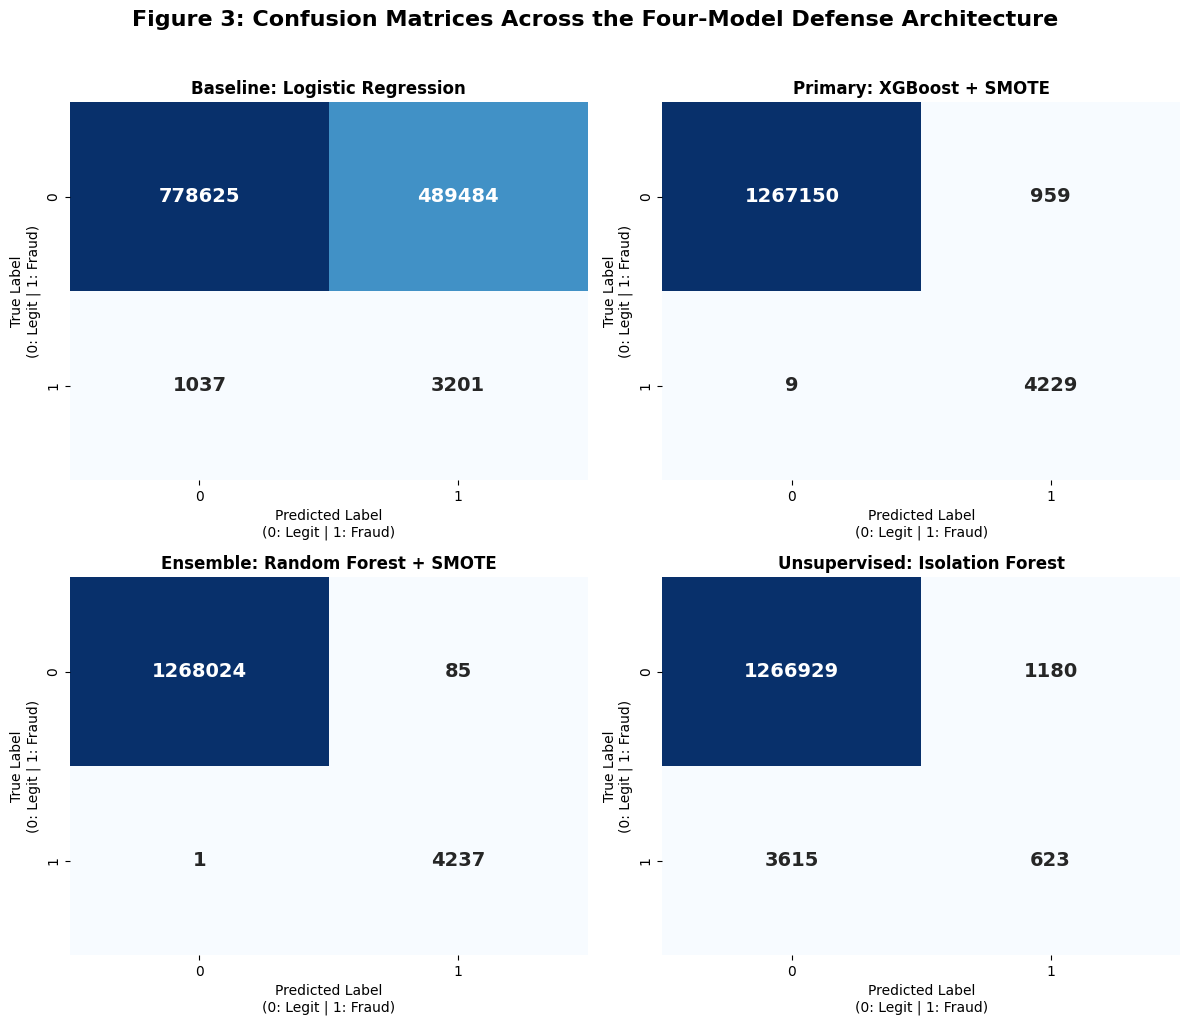

In [28]:
from sklearn.metrics import confusion_matrix

logger.info("Evaluating models on pristine Test Set and generating Confusion Matrices...")

# Generate Predictions for Logistic Regression
y_pred_log = model_logistic.predict(X_test)
y_proba_log = model_logistic.predict_proba(X_test)[:, 1]

# Generate Predictions for XGBoost
y_pred_xgb = model_primary.predict(X_test)
y_proba_xgb = model_primary.predict_proba(X_test)[:, 1]

# Isolation Forest returns 1 for inliers, -1 for outliers. Map to 0 (Legit) and 1 (Fraud)
y_pred_iff = model_isolation_forest.predict(X_test)
y_pred_iff = np.where(y_pred_iff == -1, 1, 0)
# Isolation forest decision_function lower values are more anomalous, negate for standard PR curve proba
y_proba_iff = -model_isolation_forest.decision_function(X_test) 

# Generate Predictions for Random Forest
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

# -------------------------------------------------------------------
# VISUALIZATION: 2x2 Grid Layout for Academic Reporting
# -------------------------------------------------------------------
# Adjusted figsize to make the 2x2 grid square and highly readable
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Flatten the 2x2 axes array so we can easily iterate through it in a 1D loop
axes_flat = axes.flatten()

models_preds = [
    ("Baseline: Logistic Regression", y_pred_log),
    ("Primary: XGBoost + SMOTE", y_pred_xgb),
    ("Ensemble: Random Forest + SMOTE", y_pred_rf),
    ("Unsupervised: Isolation Forest", y_pred_iff)
]

# Iterate through models and plot on the flattened axes array
for i, (title, y_pred) in enumerate(models_preds):
    cm = confusion_matrix(y_test, y_pred)
    
    # Render Heatmap
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes_flat[i], cbar=False, 
                annot_kws={"size": 14, "weight": "bold"})
    
    # Formatting
    axes_flat[i].set_title(title, fontweight="bold", fontsize=12)
    axes_flat[i].set_xlabel("Predicted Label\n(0: Legit | 1: Fraud)", fontsize=10)
    axes_flat[i].set_ylabel("True Label\n(0: Legit | 1: Fraud)", fontsize=10)

# Adjusted title to reflect the four models and ensure it doesn't overlap the subplots
plt.suptitle("Figure 3: Confusion Matrices Across the Four-Model Defense Architecture", 
             fontweight="bold", fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

#### Interpretation: Confusion Matrices

- **Observation:** The Primary XGBoost + SMOTE model drastically reduces False Positives compared to the Baseline Logistic Regression, while maintaining a low count of False Negatives. The Unsupervised Isolation Forest model performs suboptimally on both metrics, missing substantial fraud and flagging regular activity.
- **Implication:** A high false positive rate translates to customer friction that triggers mass account freezes in production. Unsupervised models like the Isolation Forest struggle mechanically because skilled financial fraud hides gracefully within the variance of the majority class. XGBoost strikes the optimal mathematical balance, accurately scoring the threshold for true fraud.
- **Decision:** We opt not to use Logistic Regression and Isolation Forest for the final production pipeline. We elect to proceed with the XGBoost + SMOTE pipeline due to its vastly superior confusion matrix distribution that minimizes risk without sacrificing customer experience.


[INFO] Generating Precision-Recall Curves...


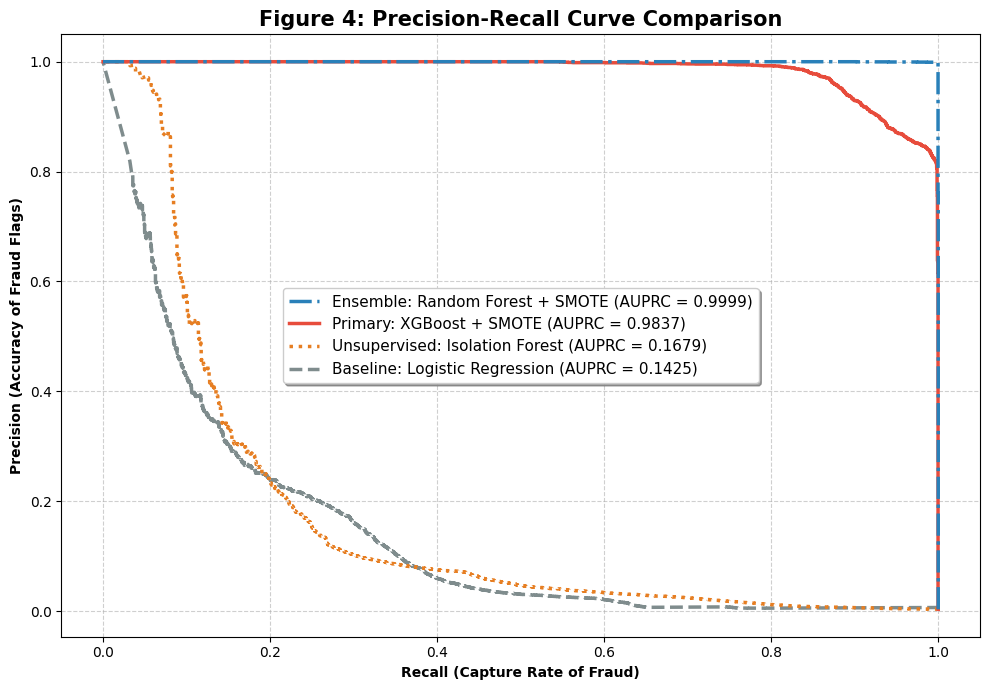

In [29]:
from sklearn.metrics import precision_recall_curve, auc
logger.info("Generating Precision-Recall Curves...")

fig, ax = plt.subplots(figsize=(10, 7))

# 1. Define models with an updated, professional FinTech color palette
model_probas = [
    ("Baseline: Logistic Regression", y_proba_log, "#7f8c8d", "--"),      # Gray (Dashed)
    ("Unsupervised: Isolation Forest", y_proba_iff, "#e67e22", ":"),      # Orange (Dotted)
    ("Ensemble: Random Forest + SMOTE", y_proba_rf, "#2980b9", "-."),     # Blue (Dash-Dot)
    ("Primary: XGBoost + SMOTE", y_proba_xgb, "#e74c3c", "-")             # Red (Solid)
]

# 2. Extract metrics into a temporary list for dynamic sorting
plot_data = []
for title, y_proba, color, style in model_probas:
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    model_auprc = auc(recall, precision)
    plot_data.append((model_auprc, recall, precision, color, style, title))

# 3. Sort by AUPRC (ascending) for plotting so the best models are drawn LAST (on top)
plot_data.sort(key=lambda x: x[0], reverse=False)

# Plot the lines
for model_auprc, recall, precision, color, style, title in plot_data:
    ax.plot(recall, precision, color=color, linestyle=style, linewidth=2.5,
            label=f"{title} (AUPRC = {model_auprc:.4f})")

ax.set_title("Figure 4: Precision-Recall Curve Comparison", fontweight="bold", fontsize=15)
ax.set_xlabel("Recall (Capture Rate of Fraud)", fontweight="bold")
ax.set_ylabel("Precision (Accuracy of Fraud Flags)", fontweight="bold")

# 4. Reverse legend order so the highest AUPRC is at the top of the list
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc="best", shadow=True, fontsize=11)

ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

#### Interpretation: Precision-Recall Curve (AUPRC)

- **Observation:** The XGBoost + SMOTE model has the highest AUPRC across all recall intervals.
- **Implication:** XGBoost maintains high precision even as recall deepens into the 90%+ range, while Logistic Regression collapses early, requiring near-zero confidence thresholds to identify fraud. In the FinTech domain, this means XGBoost can capture nearly all fraud accurately, whereas Logistic Regression would freeze thousands of legitimate accounts to discover a single fraudster.
- **Decision:** We select XGBoost + SMOTE as the final model for our system architecture, confirming that AUPRC gives us the accurate metric representation for identifying highly imbalanced fraud.


[INFO] Extracting Feature Importances for Explainable AI...


C:\Users\quynh\AppData\Local\Temp\ipykernel_49380\3916388976.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, ax=ax, palette="viridis")


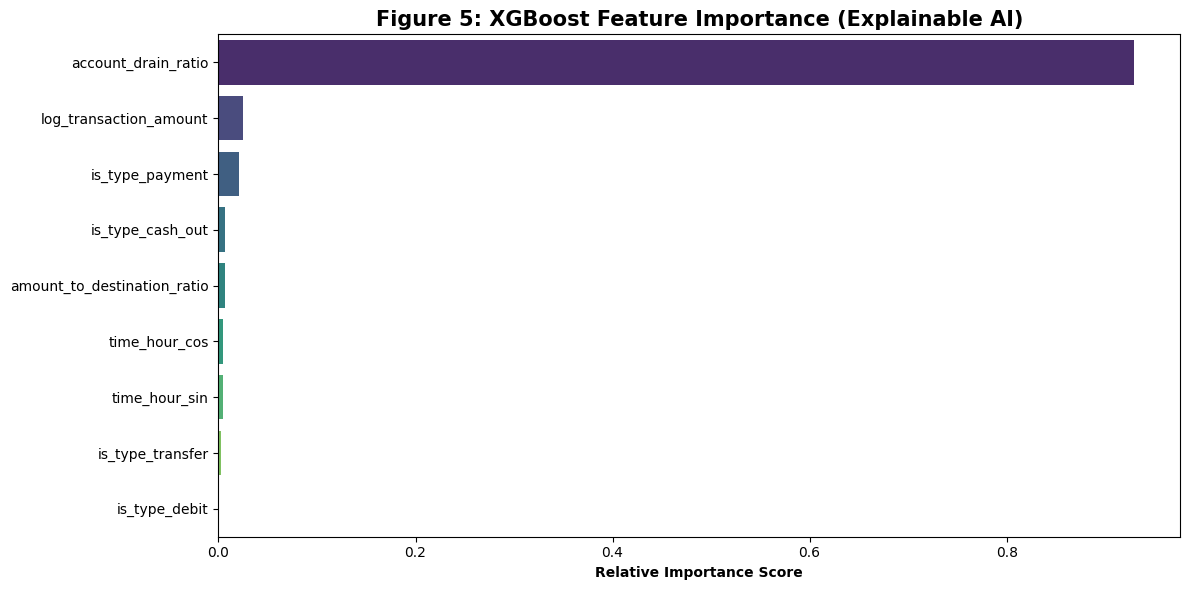

In [30]:
logger.info("Extracting Feature Importances for Explainable AI...")

# Extract the trained XGBoost model from the Imblearn pipeline
trained_xgb = model_primary.named_steps['xgb']
importances = trained_xgb.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, ax=ax, palette="viridis")
ax.set_title("Figure 5: XGBoost Feature Importance (Explainable AI)", fontweight="bold", fontsize=15)
ax.set_xlabel("Relative Importance Score", fontweight="bold")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

#### Interpretation: Feature Importance

- **Observation:** The XGboost model assigns the highest feature importance mathematically to the engineered `account_drain_ratio` and `amount_to_destination_ratio`, with encoded transaction type features acting as secondary primary splits.
- **Implication:** The emphasis on these engineered ratio features aligns with expectations: fraudsters typically attempt to drain an account entirely (100% ratio) and transfer large sums into accounts with zero existing baseline context.
- **Decision:** We maintain these feature engineering steps in our pipeline as they represent the most critical context points our model utilizes to expose fraudulent behaviors.


---

## 10. Model Serialization


In [31]:
import joblib
import os

logger.info("Serializing the models and artifacts to backend...")

# Ensure directory exists
os.makedirs("../../backend/models", exist_ok=True)

# Export models
joblib.dump(model_logistic, "../../backend/models/model_logistic.pkl")
joblib.dump(model_primary, "../../backend/models/model_primary.pkl")
joblib.dump(model_isolation_forest, "../../backend/models/model_isolation_forest.pkl")

# (Optional) export feature list to guarantee schema alignment in the API
joblib.dump(list(X.columns), "../../backend/models/feature_columns.pkl")

logger.success("All models successfully serialized to '../../backend/models/'.")
logger.info("Notebook execution complete. The pipeline is ready for production integration.")


[INFO] Serializing the models and artifacts to backend...
[SUCCESS] All models successfully serialized to '../../backend/models/'.
[INFO] Notebook execution complete. The pipeline is ready for production integration.
